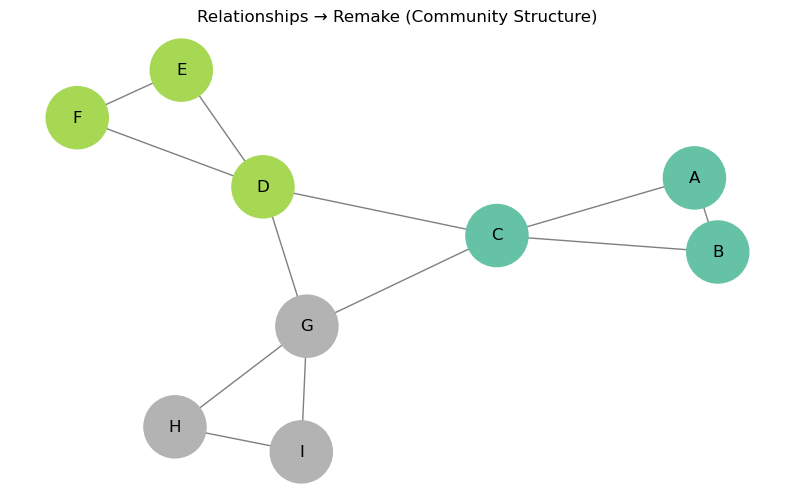

In [1]:
import networkx as nx
import matplotlib.pyplot as plt
from networkx.algorithms.community import greedy_modularity_communities

# -----------------------------
# Original relationship network
# (collaboration / social links)
# -----------------------------
edges = [
    ("A", "B"), ("A", "C"), ("B", "C"), ("C", "D"),
    ("D", "E"), ("E", "F"), ("F", "D"),
    ("G", "H"), ("H", "I"), ("I", "G"),
    ("C", "G"), ("D", "G")  # bridge connections
]

G = nx.Graph()
G.add_edges_from(edges)

# -----------------------------
# Detect communities (remake step)
# -----------------------------
communities = list(greedy_modularity_communities(G))

# Assign community colors
color_map = {}
for i, community in enumerate(communities):
    for node in community:
        color_map[node] = i

node_colors = [color_map[n] for n in G.nodes()]

# -----------------------------
# Layout
# -----------------------------
plt.figure(figsize=(10, 6))
pos = nx.spring_layout(G, seed=42)

# -----------------------------
# Draw original network (remade structure)
# -----------------------------
nx.draw_networkx_nodes(
    G, pos,
    node_color=node_colors,
    cmap=plt.cm.Set2,
    node_size=2000
)

nx.draw_networkx_edges(G, pos, alpha=0.5)
nx.draw_networkx_labels(G, pos)

plt.title("Relationships → Remake (Community Structure)")
plt.axis("off")
plt.show()